### This notebook compute "E9. Number of hydropower and electricity infrastructure exposed to climate hazards" indicator for the 27 basins of IKI Project

Spanish: Número de obras de infraestructura hidro-energética y eléctrica expuesta a peligros climáticos 

**Created:** 8/2025 by Serena Gilson  

**Assumptions:** Any COMIDs that do not have hydropower or electricity infrastructure will be populated with NaN.

**N/A Handling:** Replace COMIDs with 0 (i.e., no infrastructure features) with NaN.   

**Notes:**  
General Methodology:  
1. Combine reservoir (embalses) and hydroelectric power plants (centrales hidroelectricas, "CH") layer into a single infrastructure object. Note: there are two CH scenarios.  
2. Spatial join infrastructure with COMIDs.  
3. Calculate the total number of infrasturcture features per COMID.  
4. Replace any 0s with NaN.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"

# define filepaths for input data
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"

embalses =  master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "embalses_IKI.shp"

ch_baseline = master_path / "Indicadores" / "Datos_COES" / "COES_CH_EnOperacion.shp"

ch_future = master_path / "Indicadores" / "Datos_COES" / "COES_CH_Proyectadas.shp" 

In [4]:
# set up indicator ID and get scenarios from database
IndID= 209 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
# read in input data and ensure all shapefiles are set to the same CRS
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

embalses_gdf = gpd.read_file(embalses).to_crs('EPSG:32718')

ch_baseline_gdf = gpd.read_file(ch_baseline).to_crs('EPSG:32718')    

ch_future_gdf = gpd.read_file(ch_future).to_crs('EPSG:32718')   

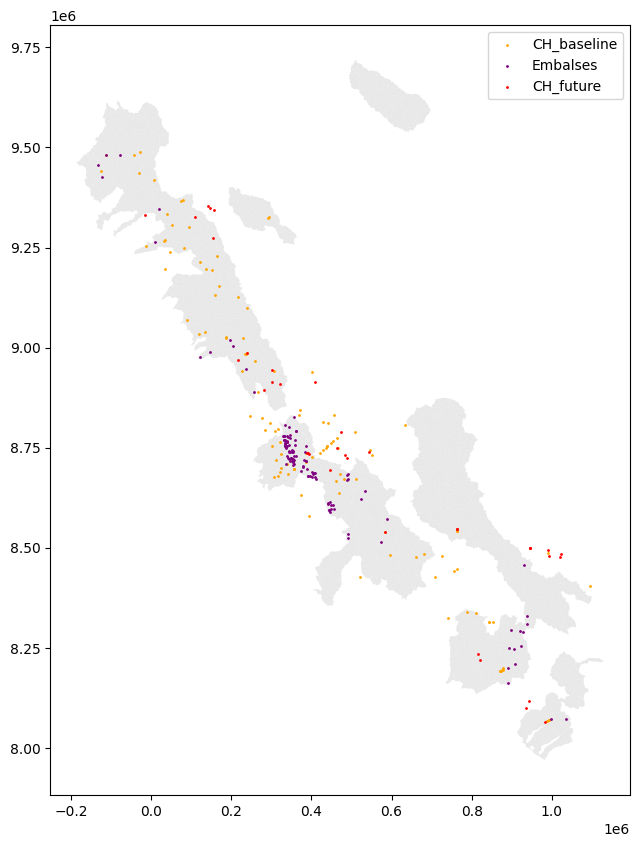

In [6]:
#plot CH baseline, CH future,  embalses and subbasins_gdf
fig, ax = plt.subplots(figsize=(10, 10))
subbasins_gdf.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)
ch_baseline_gdf.plot(ax=ax, color='orange',markersize= 1, label='CH_baseline')
embalses_gdf.plot(ax=ax, color='purple', markersize= 1, label='Embalses')
ch_future_gdf.plot(ax=ax, color='red', markersize= 1, label='CH_future')
plt.legend()
plt.show()

In [7]:
# FUNCTION to calculate infrastructure counts per COMID
def calculate_infrastructure_counts(subbasins_gdf, ch_gdf, embalses_gdf):
    """
    Calculate total infrastructure counts per COMID.

    Parameters:
    - subbasins_gdf: GeoDataFrame with COMID polygons
    - ch_gdf: GeoDataFrame with CH points for the scenario
    - embalses_gdf: GeoDataFrame with embalses points

    Returns:
    - GeoDataFrame of subbasins with 'total_infrastructure' column
    """
    # Combine all layers
    all_infra = gpd.GeoDataFrame(pd.concat([ch_gdf, embalses_gdf], ignore_index=True))
    
    # Ensure same CRS
    all_infra = all_infra.set_crs(subbasins_gdf.crs, allow_override=True)
    
    # Spatial join: count points within each COMID
    join_gdf = gpd.sjoin(
        subbasins_gdf[['COMID', 'geometry']],  # left (subbasins)
        all_infra[['geometry']],               # right (points)
        how='left', 
        predicate='contains'
    )
    
    # Count infrastructure points per COMID
    counts = join_gdf.groupby('COMID').size().reset_index(name='total_infrastructure')
    
    # Merge back to subbasins
    subbasins_with_counts = subbasins_gdf.merge(counts, on='COMID', how='left')
    
    # Replace 0 with NaN
    subbasins_with_counts['total_infrastructure'] = subbasins_with_counts['total_infrastructure'].replace(0, np.nan)
    
    return subbasins_with_counts

In [8]:
# Calculate counts for all scenarios and insert into sqlite database
# for now the results are the same for the two different climate scenarios, but we want to have values for both in the DB
infrastructure_scenarios = {
    1: ch_baseline_gdf,  # baseline
    2: ch_future_gdf,     # future 2050 (CMIP6 8.5)
    3: ch_future_gdf # future 2050 (CMIP6 4.5)
}

rows_to_insert = []

for scn_id, ch_gdf in infrastructure_scenarios.items():
    subbasins_with_counts = calculate_infrastructure_counts(subbasins_gdf, ch_gdf, embalses_gdf)
    
    # Prepare rows for database
    for _, row in subbasins_with_counts.iterrows():
        comid = row['COMID']
        value = row['total_infrastructure']
        rows_to_insert.append((scn_id, IndID, comid, value))

# %%
# Insert results into the database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [9]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

# --- CHECK value statistics before insert ---
values_df = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])

# Show stats separately for each scenario
for scn_id in scenario_ids:
    scn_values = values_df[values_df['ScnID'] == scn_id]['Value']
    stats = scn_values.agg(['min', 'max', 'count'])
    print(f"\n=== Values to be inserted for Scenario {scn_id} ===")
    print(stats)

# --- CHECK for duplicates in rows_to_insert ---
duplicates = values_df.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("\nDuplicates in rows_to_insert:")
print(values_df[duplicates])

Indicator 209  Min: 1, Max: 9.450000000000001

=== Values to be inserted for Scenario 1 ===
min         1
max         9
count    3655
Name: Value, dtype: int64

=== Values to be inserted for Scenario 2 ===
min         1
max         9
count    3655
Name: Value, dtype: int64

=== Values to be inserted for Scenario 3 ===
min         1
max         9
count    3655
Name: Value, dtype: int64

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [10]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()